# Phys-gated Morgan quantile mixture of experts

This notebook fits `PhysGatedMorganQuantileMoE` (see `src/models/moe_quantile.py`).

**Routing:** By default, **K** gated experts are trained with responsibilities from a **Gaussian mixture** on **MolWt, MolLogP, TPSA**, and each expert is an `EnsembleQuantileRegressor` of **HistGradientBoosting** quantile models on **`morgan_r1_count_1024`**.

**Optional extensions** (toggle in the fit cell):

- **PCA + GPR:** PCA of the Morgan matrix feeds a **multi-output Gaussian process** trained to match GMM responsibilities; at test time, gated weights blend **GMM posteriors** and **softmax(GPR outputs)** on PCA scores (`gmm_gpr_blend`).
- **Ungated experts:** Extra quantile ensembles fit with **uniform** sample weights; they receive a fixed share **`ungated_mass`** of the mixture (split across `n_ungated_experts`), independent of phys/GPR routing.

**Plots:** observed vs median with quantile bands, gate-space scatter colored by **dominant expert in the full mixture** (gated + ungated), and interval-width distribution.

Run from the repo root or `notebooks/`; the first code cell adds `src/` to `sys.path`. `load_data.train` may download the training CSV from Hugging Face on first import. **GPR** is trained on a **subsample** when `gpr_max_train_samples` is set (default in the class) to keep cost manageable on large tables.

In [3]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rdkit import Chem
from sklearn.model_selection import train_test_split

_REPO = Path.cwd().resolve()
if not (_REPO / "src" / "baseline.py").exists():
    _REPO = _REPO.parent
sys.path.insert(0, str(_REPO / "src"))

from baseline import BaselineCVConfig, prepare_training_data
from features_data import build_descriptor_matrix, build_rdkit_phys_props_matrix
from load_data import train
from models import PhysGatedMorganQuantileMoE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 0
Y_COL = "pEC50"
DESCRIPTOR = "morgan_r1_count_1024"
GATE_NAMES = ("MolWt", "MolLogP", "TPSA", "NumHAcceptors", "NumHDonors")


def moe_dominant_expert_index(moe, X_gate, X_morgan):
    """Argmax weight over gated (GMM ± PCA→GPR blend) + ungated experts.

    Implemented from ``moe`` attributes only (no private methods) so it still
    works if the Jupyter kernel has an older ``PhysGatedMorganQuantileMoE`` class
    or after ``importlib.reload`` quirks. Prefer ``moe.gated_mixing_weights`` in
    new code when the kernel was restarted after updating ``openadnet``.
    """
    X_gate = np.asarray(X_gate, dtype=np.float64)
    X_morgan = np.asarray(X_morgan, dtype=np.float64)
    n = X_gate.shape[0]
    Zg = moe._gate_pre.transform(X_gate)
    pi = moe._gmm.predict_proba(Zg)
    pi = np.maximum(pi, float(getattr(moe, "weight_floor", 1e-6)))
    pi_gmm = pi / pi.sum(axis=1, keepdims=True)

    beta = float(getattr(moe, "gmm_gpr_blend", 1.0))
    pca = getattr(moe, "_pca_morgan", None)
    gpr = getattr(moe, "_gpr_router", None)
    if pca is not None and gpr is not None and beta < 1.0 - 1e-15:
        Zp = pca.transform(X_morgan)
        raw = gpr.predict(Zp)
        z = raw - np.max(raw, axis=1, keepdims=True)
        e = np.exp(z)
        pi_gpr = e / np.sum(e, axis=1, keepdims=True)
        pi_gate = beta * pi_gmm + (1.0 - beta) * pi_gpr
        pi_gate = pi_gate / pi_gate.sum(axis=1, keepdims=True)
    else:
        pi_gate = pi_gmm

    m_u = float(getattr(moe, "ungated_mass", 0.0))
    scale_g = 1.0 - m_u
    w_g = scale_g * pi_gate
    ung = getattr(moe, "_ungated_experts", None) or []
    U = len(ung)
    if U == 0:
        full = w_g
    else:
        w_u = np.full((n, U), m_u / U, dtype=np.float64)
        full = np.hstack([w_g, w_u])
    return np.argmax(full, axis=1), int(full.shape[1])

/home/ericb/Documents/openadnet/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load aligned molecules, Morgan FP, and gate features

`X_gate` uses columns 0–2 of `build_rdkit_phys_props_matrix` (same order as `RDKIT_PHYS_PROP_NAMES` in `features_data.py`).

In [4]:
cfg = BaselineCVConfig(y_col=Y_COL)
mols = list(train["SMILES"].apply(Chem.MolFromSmiles))
y, mols_f, mask = prepare_training_data(train, mols, y_col=cfg.y_col)

X_phys = build_rdkit_phys_props_matrix(mols_f).astype(np.float64)
X_gate = X_phys[:, :3]
X_morgan = build_descriptor_matrix(DESCRIPTOR, mols_f).astype(np.float64)

print(
    f"n={len(y)}  {DESCRIPTOR} {X_morgan.shape}  gate {X_gate.shape}  "
    f"finite y: {np.isfinite(y).all()}"
)

n=4139  morgan_r1_count_1024 (4139, 1024)  gate (4139, 3)  finite y: True


## 5-fold cross-validation (`BaselineCVConfig`)

Same outer splits as `baseline.run_baseline_cv` (`KFold` with `n_splits`, `shuffle`, `cv_random_state` from `BaselineCVConfig`). Metrics: **RMSE / MAE / R²** on the **0.5** quantile prediction, **mean pinball** averaged over all fitted quantile levels, and **empirical coverage** in the **[q_low, q_high]** band vs nominal **q_high − q_low**.

Edit **`MOE_PARAMS`** below to match the hold-out fit; **`_moe_kw`** is reused in the next fit cell. Run this cell before fitting if you use the shared `_moe_kw`.

In [ ]:
from baseline import BaselineCVConfig
from IPython.display import display

from models.moe_quantile import cross_validate_phys_gated_morgan_quantile_moe

USE_PCA_GPR_AND_UNGATED = False

MOE_PARAMS = dict(
    n_components_gmm=2,
    quantile_levels=(0.2, 0.5, 0.8),
    n_ensemble_members=5,
    gmm_kwargs={"covariance_type": "spherical", "n_init": 5},
    hgb_kwargs={"max_iter": 1200, "max_depth": 16},
    random_state=RANDOM_STATE,
)

quantile_levels = tuple(MOE_PARAMS["quantile_levels"])

_moe_kw = dict(MOE_PARAMS)
if USE_PCA_GPR_AND_UNGATED:
    _moe_kw.update(
        {
            "pca_n_components_for_gpr": 6,
            "gmm_gpr_blend": 0.05,
            "n_ungated_experts": 1,
            "ungated_mass": 0.01,
            "gpr_max_train_samples": 100,
            "gpr_alpha": 0.001,
        }
    )

cv_cfg = BaselineCVConfig(y_col=Y_COL)
cv_summary, cv_detail = cross_validate_phys_gated_morgan_quantile_moe(
    y,
    X_gate,
    X_morgan,
    moe_params=_moe_kw,
    config=cv_cfg,
)
display(cv_summary)
print("Per-fold RMSE (median):", np.round(cv_detail["rmse"], 4))
print(
    f"Per-fold coverage [{quantile_levels[0]}, {quantile_levels[-1]}]: "
    f"nominal={cv_detail['nominal_coverage']:.2f}",
    np.round(cv_detail["coverage"], 3),
)

## Train / test split and minimal `dataset` wrapper

`PhysGatedMorganQuantileMoE` only needs `.y` and `len(dataset)` for row alignment; features are passed as `X_gate` / `X_morgan`.

In [5]:
class YOnlyDataset:
    def __init__(self, y: np.ndarray) -> None:
        yy = np.asarray(y, dtype=np.float64)
        self.y = yy.reshape(-1, 1) if yy.ndim == 1 else yy

    def __len__(self) -> int:
        return int(self.y.shape[0])


Xm_tr, Xm_te, Xg_tr, Xg_te, y_tr, y_te = train_test_split(
    X_morgan,
    X_gate,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)
ds_tr = YOnlyDataset(y_tr)
ds_te = YOnlyDataset(y_te)
print(f"train {len(ds_tr)}  test {len(ds_te)}")

train 3311  test 828


## Fit MoE (hold-out train split)

Hyperparameters come from the **5-fold CV** cell (`MOE_PARAMS`, `_moe_kw`, `quantile_levels`, `USE_PCA_GPR_AND_UNGATED`). Run that cell first so `_moe_kw` exists.

Set **`USE_PCA_GPR_AND_UNGATED = True`** in the CV cell to enable **PCA → GPR** and **ungated** experts for both CV and this fit.

In [30]:
# Uses `quantile_levels`, `USE_PCA_GPR_AND_UNGATED`, and `_moe_kw` from the CV cell above.
moe = PhysGatedMorganQuantileMoE(**_moe_kw)
moe.fit(ds_tr, X_gate=Xg_tr, X_morgan=Xm_tr)
print(
    "Fitted MoE.",
    "PCA+GPR+ungated" if USE_PCA_GPR_AND_UNGATED else "phys GMM only",
)

Fitted MoE. phys GMM only


## Predictions and metrics on the test set

In [31]:
q_te = moe.predict_quantiles(ds_te, X_gate=Xg_te, X_morgan=Xm_te)
i_lo, i_med, i_hi = 0, 1, 2
q_lo = q_te[:, 0, i_lo]
q_med = q_te[:, 0, i_med]
q_hi = q_te[:, 0, i_hi]
y_flat = y_te.ravel()

rmse = float(np.sqrt(np.mean((q_med - y_flat) ** 2)))
mae = float(np.mean(np.abs(q_med - y_flat)))
pinball = moe.evaluate_pinball_loss(ds_te, X_gate=Xg_te, X_morgan=Xm_te)
cover = float(np.mean((y_flat >= q_lo) & (y_flat <= q_hi)))
nominal = quantile_levels[i_hi] - quantile_levels[i_lo]
width = q_hi - q_lo

print(f"Test RMSE (median): {rmse:.4f}")
print(f"Test MAE (median):  {mae:.4f}")
print(f"Mean pinball (over quantile levels): {pinball:.4f}")
print(f"Empirical coverage [{quantile_levels[i_lo]}, {quantile_levels[i_hi]}]: {cover:.3f}  (nominal ~{nominal:.2f})")
print(f"Mean interval width: {width.mean():.4f}")

dominant_expert_te, n_route_experts = moe_dominant_expert_index(moe, Xg_te, Xm_te)

Test RMSE (median): 0.7085
Test MAE (median):  0.5138
Mean pinball (over quantile levels): 0.2206
Empirical coverage [0.2, 0.8]: 0.370  (nominal ~0.60)
Mean interval width: 0.6445


## Plot 1 — Observed vs median with quantile intervals

Each point shows the **0.1–0.9** quantile range as a vertical segment (not calibrated conformal intervals). **Color** is the **dominant expert in the full mixture** (largest weight among gated experts—phys GMM blended with optional PCA→GPR routing—plus any ungated experts).

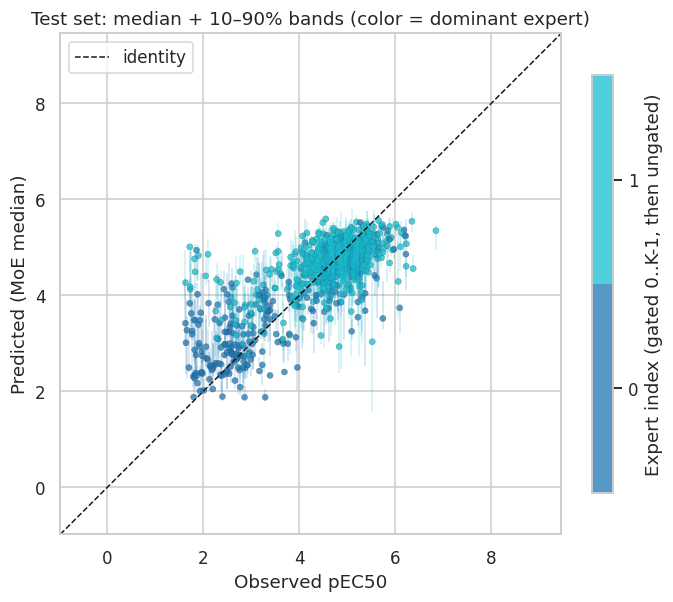

In [32]:
from matplotlib import colormaps

fig, ax = plt.subplots(figsize=(6.5, 6))
lo, hi = float(y_flat.min()), float(y_flat.max())
pad = 0.5 * (hi - lo)
lims = (lo - pad, hi + pad)

Kplot = int(n_route_experts)
cmap = colormaps["tab10"].resampled(max(Kplot, 1))

for yi, lo_i, hi_i, k in zip(y_flat, q_lo, q_hi, dominant_expert_te, strict=True):
    t = float(k) / max(Kplot - 1, 1) if Kplot > 1 else 0.0
    ax.vlines(yi, lo_i, hi_i, colors=cmap(t), alpha=0.22, linewidth=1)
sc = ax.scatter(
    y_flat,
    q_med,
    s=16,
    alpha=0.75,
    c=dominant_expert_te,
    cmap=cmap,
    vmin=-0.5,
    vmax=Kplot - 0.5,
    edgecolors="0.2",
    linewidths=0.2,
)
ax.plot(lims, lims, "k--", linewidth=1, label="identity")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(f"Observed {Y_COL}")
ax.set_ylabel("Predicted (MoE median)")
ax.set_title("Test set: median + 10–90% bands (color = dominant expert)")
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_ticks(np.arange(Kplot))
cbar.set_label("Expert index (gated 0..K-1, then ungated)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Plot 2 — Gate space (MolWt vs MolLogP) colored by dominant expert

Same **full-mixture** dominant index as plot 1 (gated weights from GMM ± PCA→GPR, plus ungated share).

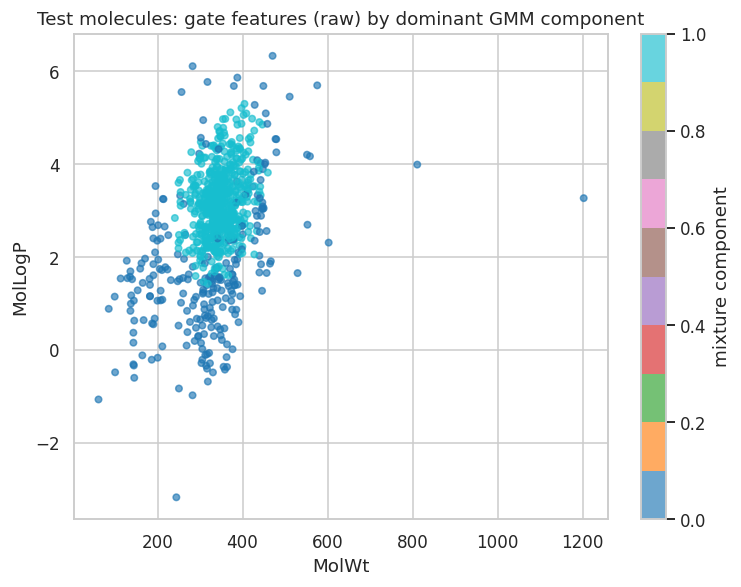

In [ ]:
from matplotlib import colormaps as _cmaps

K2 = int(n_route_experts)
cmap2 = _cmaps["tab10"].resampled(max(K2, 1))

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(
    Xg_te[:, 0],
    Xg_te[:, 1],
    c=dominant_expert_te,
    cmap=cmap2,
    vmin=-0.5,
    vmax=K2 - 0.5,
    alpha=0.65,
    s=18,
)
cb = plt.colorbar(sc, ax=ax)
cb.set_ticks(np.arange(K2))
cb.set_label("Expert index (full mixture)")
ax.set_xlabel(GATE_NAMES[0])
ax.set_ylabel(GATE_NAMES[1])
ax.set_title("Test molecules: gate features (raw) by dominant expert")
plt.tight_layout()
plt.show()

## Plot 3 — Distribution of predicted interval widths

Width = $\hat{q}_{0.9} - \hat{q}_{0.1}$ per compound.

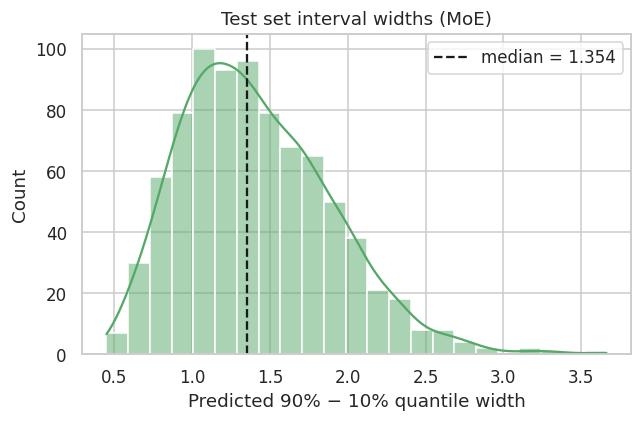

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(width, kde=True, ax=ax, color="C2")
ax.axvline(float(np.median(width)), color="k", linestyle="--", label=f"median = {np.median(width):.3f}")
ax.set_xlabel("Predicted 90% − 10% quantile width")
ax.set_ylabel("Count")
ax.set_title("Test set interval widths (MoE)")
ax.legend()
plt.tight_layout()
plt.show()